**RNN vs TRANSFORMER FOR TIME SERIES**




DATASET INFORMATION
Dataset: Hourly Energy Consumption (AEP)
Source: Kaggle - PJM Interconnection
Total Samples: 121273
Number of Features: 1
Sequence Length: 24
Prediction Horizon: 1
Primary Metric: RMSE
Metric Justification: 
RMSE is chosen to penalize large errors in energy load forecasting, which 
is critical for maintaining grid stability and avoiding power outages.



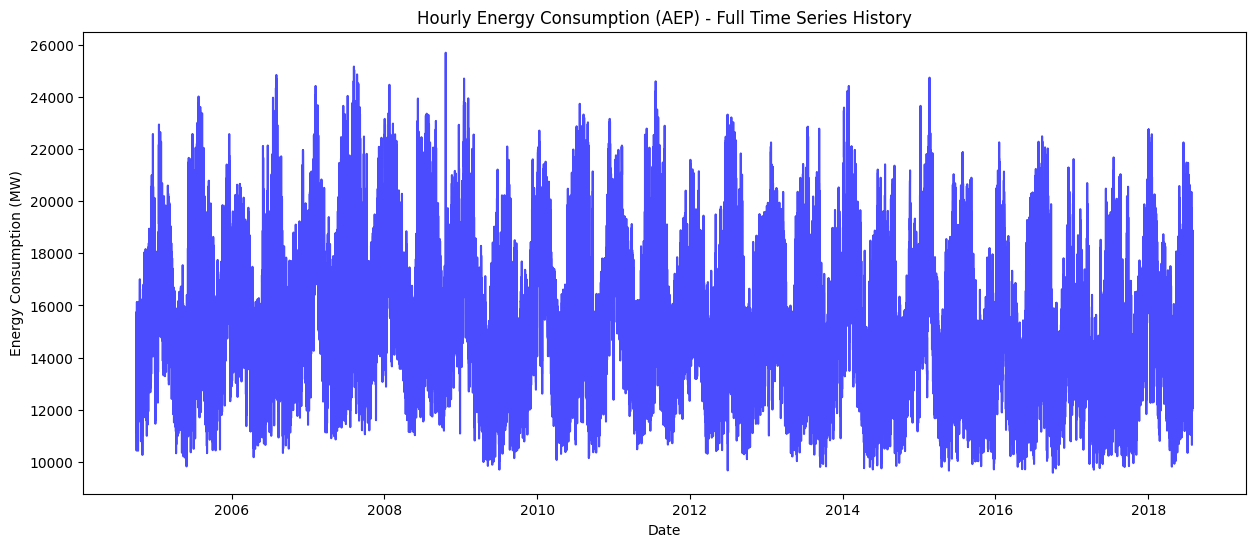


--- Seasonal Decomposition (First 500 Hours) ---


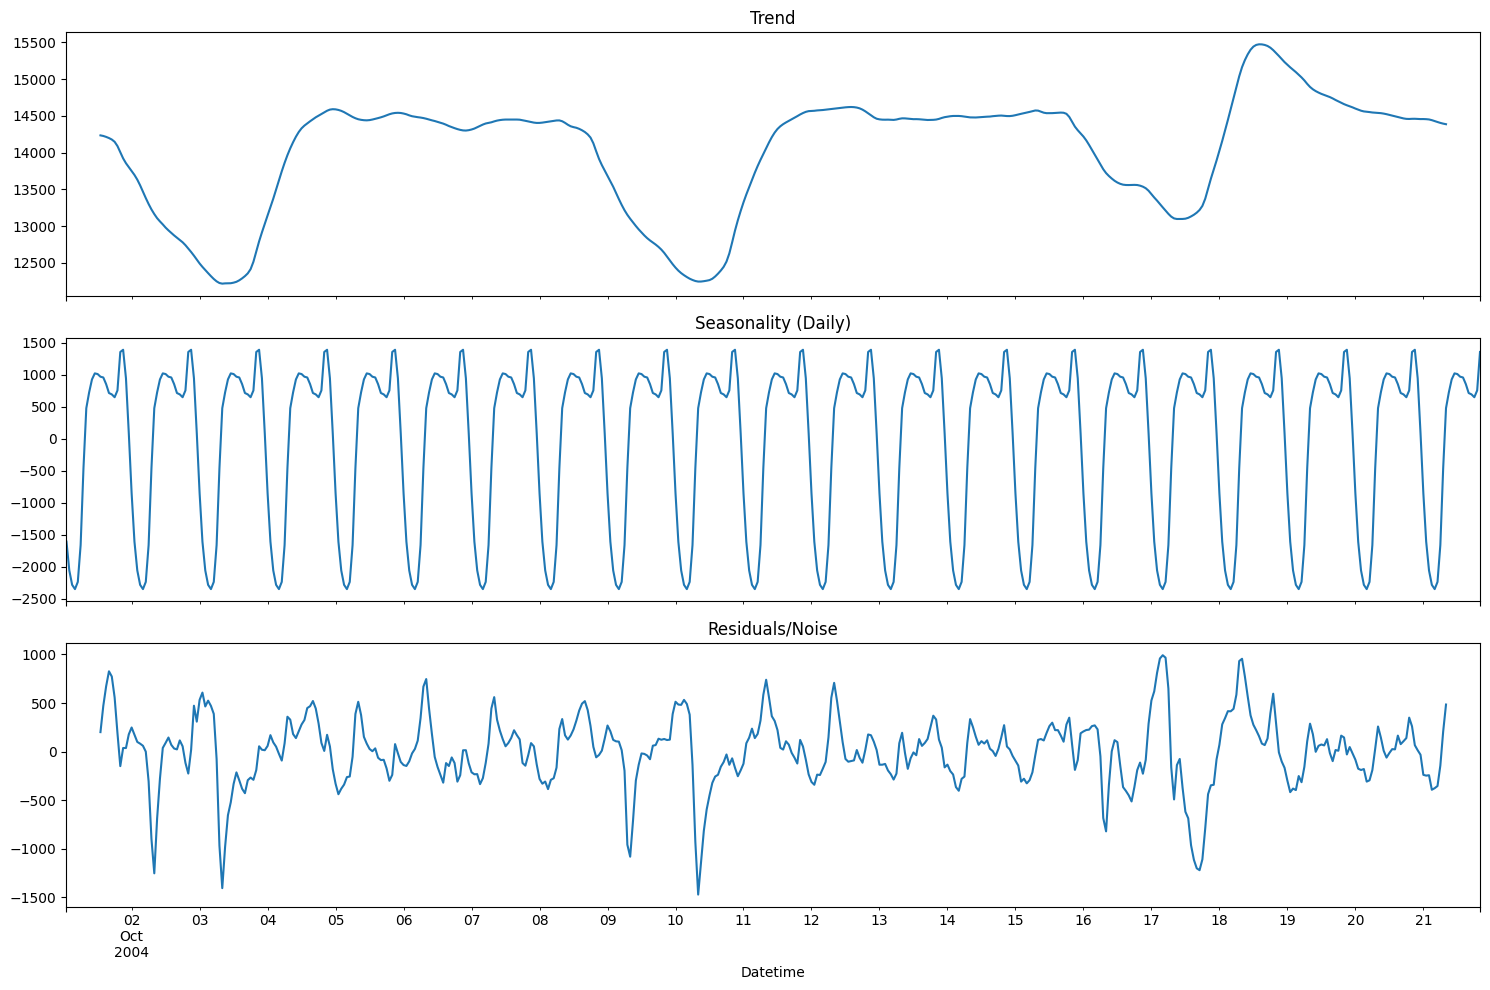


--- Stationarity Analysis (Augmented Dickey-Fuller Test) ---
ADF Statistic: -5.7381
p-value: 0.0000
Result: Series is stationary (Reject Null Hypothesis)

Train/Test Split: 90/10
Training Samples: 109121
Test Samples: 12104
IMPORTANT: Temporal split used (NO shuffling)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
import os
import time

# ==========================================
# PART 1: DATASET LOADING AND EXPLORATION
# ==========================================

dataset_name = "Hourly Energy Consumption (AEP)"
dataset_source = "Kaggle - PJM Interconnection"
n_samples = len(data)
n_features = 1
sequence_length = 24
prediction_horizon = 1
problem_type = "time_series_forecasting"

# Primary metric selection
primary_metric = "RMSE"
metric_justification = """
RMSE is chosen to penalize large errors in energy load forecasting, which
is critical for maintaining grid stability and avoiding power outages.
"""

print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

# ==========================================
# 1.2 Time Series Exploration
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose

def explore_time_series(df, column='AEP_MW'):
    # 1. Basic Time Series Plot
    plt.figure(figsize=(15, 6))
    plt.plot(df.index, df[column], color='blue', alpha=0.7)
    plt.title(f"{dataset_name} - Full Time Series History")
    plt.xlabel("Date")
    plt.ylabel("Energy Consumption (MW)")
    plt.show()

    # 2. Check for Trends and Seasonality (Decomposition)
    print("\n--- Seasonal Decomposition (First 500 Hours) ---")
    decomposition = seasonal_decompose(df[column].iloc[:500], model='additive', period=24)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
    decomposition.trend.plot(ax=ax1, title="Trend")
    decomposition.seasonal.plot(ax=ax2, title="Seasonality (Daily)")
    decomposition.resid.plot(ax=ax3, title="Residuals/Noise")
    plt.tight_layout()
    plt.show()

    # 3. Stationarity Test (ADF Test)
    print("\n--- Stationarity Analysis (Augmented Dickey-Fuller Test) ---")
    result = adfuller(df[column].values[:5000])
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

    if result[1] <= 0.05:
        print("Result: Series is stationary (Reject Null Hypothesis)")
    else:
        print("Result: Series is non-stationary (Fail to Reject Null Hypothesis)")

explore_time_series(df)

# ==========================================
# 1.3 Data Preprocessing & Sequence Creation
# ==========================================

def preprocess_timeseries(data):
    scaler = MinMaxScaler()
    data_cleaned = pd.DataFrame(data).dropna().values
    scaled_data = scaler.fit_transform(data_cleaned)
    return scaled_data, scaler

def create_sequences(data, seq_length, pred_horizon):
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length : i + seq_length + pred_horizon])
    return np.array(X), np.array(y)

split_idx = int(n_samples * 0.9)
train_raw = data[:split_idx]
test_raw = data[split_idx:]

train_scaled, scaler = preprocess_timeseries(train_raw)
test_scaled = scaler.transform(test_raw)

X_train, y_train = create_sequences(train_scaled, sequence_length, prediction_horizon)
X_test, y_test = create_sequences(test_scaled, sequence_length, prediction_horizon)

train_test_ratio = "90/10"
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("IMPORTANT: Temporal split used (NO shuffling)")


RNN MODEL TRAINING
Epoch 1/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 75s 23ms/step - loss: 0.0017 - mae: 0.0247 - val_loss: 2.8275e-04 - val_mae: 0.0125
Epoch 2/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 84s 24ms/step - loss: 3.4577e-04 - mae: 0.0138 - val_loss: 2.1115e-04 - val_mae: 0.0106
Epoch 3/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 71s 23ms/step - loss: 2.7163e-04 - mae: 0.0122 - val_loss: 2.0113e-04 - val_mae: 0.0104
Epoch 4/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 70s 23ms/step - loss: 2.3711e-04 - mae: 0.0113 - val_loss: 2.1468e-04 - val_mae: 0.0112
Epoch 5/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 72s 23ms/step - loss: 2.0751e-04 - mae: 0.0105 - val_loss: 1.6743e-04 - val_mae: 0.0093
Epoch 6/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 70s 23ms/step - loss: 1.8701e-04 - mae: 0.0100 - val_loss: 1.5274e-04 - val_mae: 0.0088
Epoch 7/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 70s 23ms/step - loss: 1.7221e-04 - mae: 0.0096 - val_loss: 1.7318e-04 - val_mae: 0.0099
Epoch 8/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 84s 23ms/step - loss: 1.6312e-04

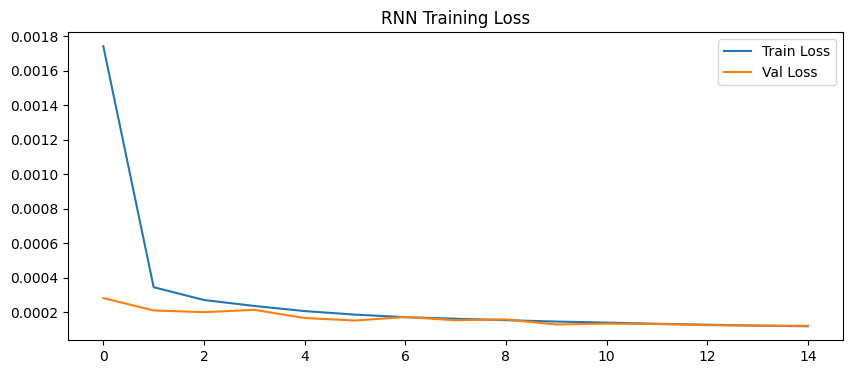

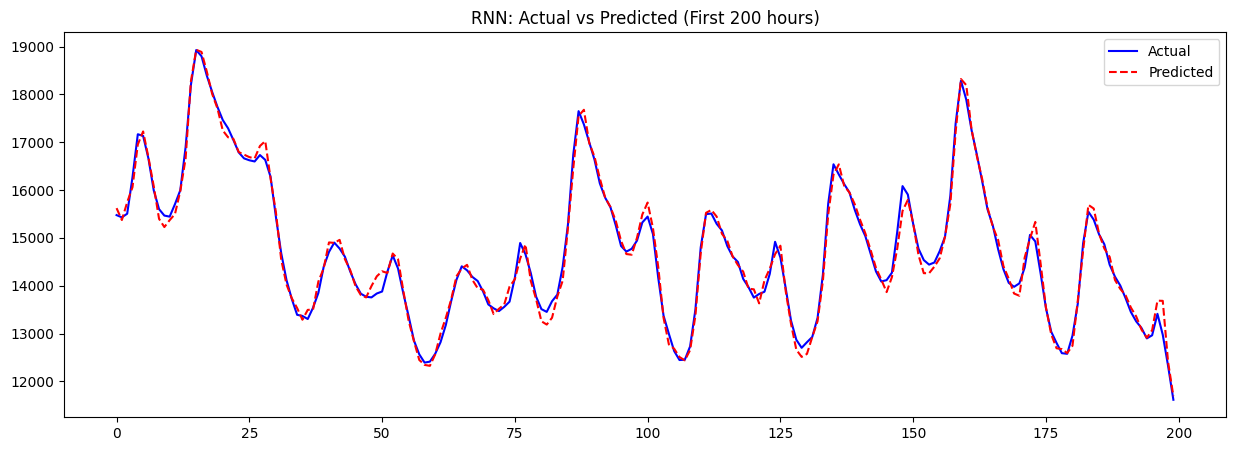

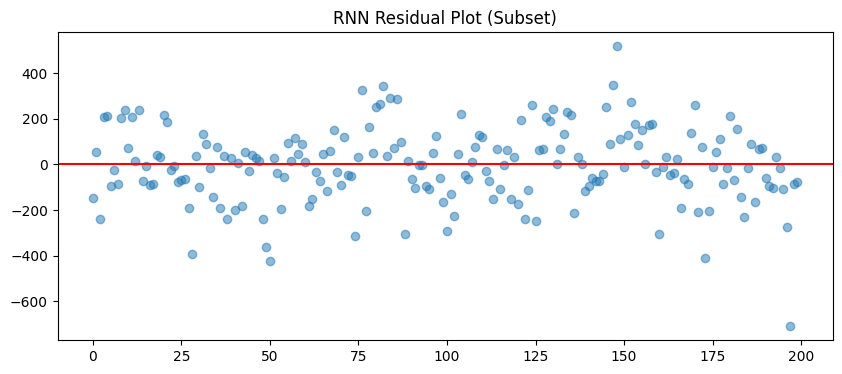

In [ ]:
# ==========================================
# PART 2: RNN (LSTM) IMPLEMENTATION
# ==========================================

from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    model = models.Sequential()

    model.add(layers.Input(shape=input_shape))
    for i in range(n_layers):

        is_last_rnn = (i == n_layers - 1)

        if model_type == 'LSTM':
            model.add(layers.LSTM(hidden_units, return_sequences=not is_last_rnn))
        else:
            model.add(layers.GRU(hidden_units, return_sequences=not is_last_rnn))

    model.add(layers.Dense(output_size))

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model


rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), 64, 2, prediction_horizon)

print("\nRNN MODEL TRAINING")
rnn_start_time = time.time()

# Train the model with loss tracking
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

rnn_training_time = time.time() - rnn_start_time

rnn_initial_loss = history_rnn.history['loss'][0]
rnn_final_loss = history_rnn.history['loss'][-1]

print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")


def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

rnn_preds_scaled = rnn_model.predict(X_test)


y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
rnn_preds_inv = scaler.inverse_transform(rnn_preds_scaled.reshape(-1, 1))

rnn_mae = mean_absolute_error(y_test_inv, rnn_preds_inv)
rnn_rmse = np.sqrt(mean_squared_error(y_test_inv, rnn_preds_inv))
rnn_mape = calculate_mape(y_test_inv, rnn_preds_inv)
rnn_r2 = r2_score(y_test_inv, rnn_preds_inv)

print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


# Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('RNN Training Loss')
plt.legend()
plt.show()

# Actual vs Predicted
plt.figure(figsize=(15, 5))
plt.plot(y_test_inv[:200], label='Actual', color='blue')
plt.plot(rnn_preds_inv[:200], label='Predicted', color='red', linestyle='--')
plt.title('RNN: Actual vs Predicted (First 200 hours)')
plt.legend()
plt.show()

# Residuals
plt.figure(figsize=(10, 4))
residuals = y_test_inv - rnn_preds_inv
plt.scatter(range(len(residuals[:200])), residuals[:200], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('RNN Residual Plot (Subset)')
plt.show()


TRANSFORMER MODEL TRAINING
Epoch 1/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 217s 67ms/step - loss: 0.0037 - mae: 0.0283 - val_loss: 2.6857e-04 - val_mae: 0.0124
Epoch 2/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 203s 66ms/step - loss: 4.3199e-04 - mae: 0.0160 - val_loss: 2.2709e-04 - val_mae: 0.0117
Epoch 3/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 200s 65ms/step - loss: 3.2414e-04 - mae: 0.0138 - val_loss: 1.9416e-04 - val_mae: 0.0108
Epoch 4/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 2.8007e-04 - mae: 0.0127 - val_loss: 1.8395e-04 - val_mae: 0.0106
Epoch 5/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 2.5568e-04 - mae: 0.0119 - val_loss: 1.5731e-04 - val_mae: 0.0094
Epoch 6/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 201s 65ms/step - loss: 2.1204e-04 - mae: 0.0110 - val_loss: 1.3864e-04 - val_mae: 0.0086
Epoch 7/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 203s 66ms/step - loss: 1.9887e-04 - mae: 0.0107 - val_loss: 1.3082e-04 - val_mae: 0.0084
Epoch 8/15
3069/3069 ━━━━━━━━━━━━━━━━━━━━ 225s 73ms/step - 

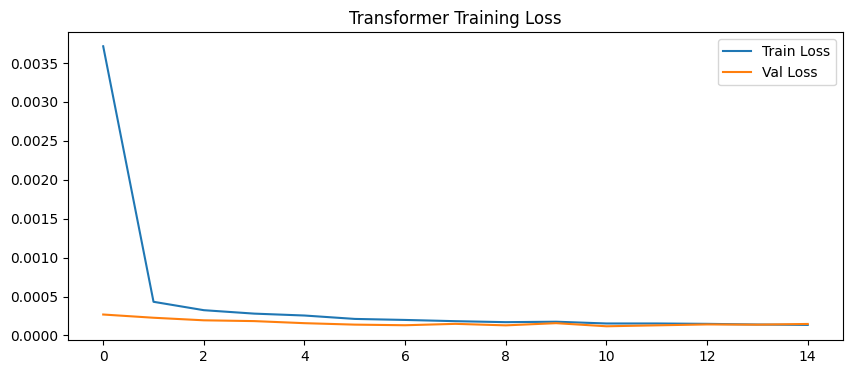

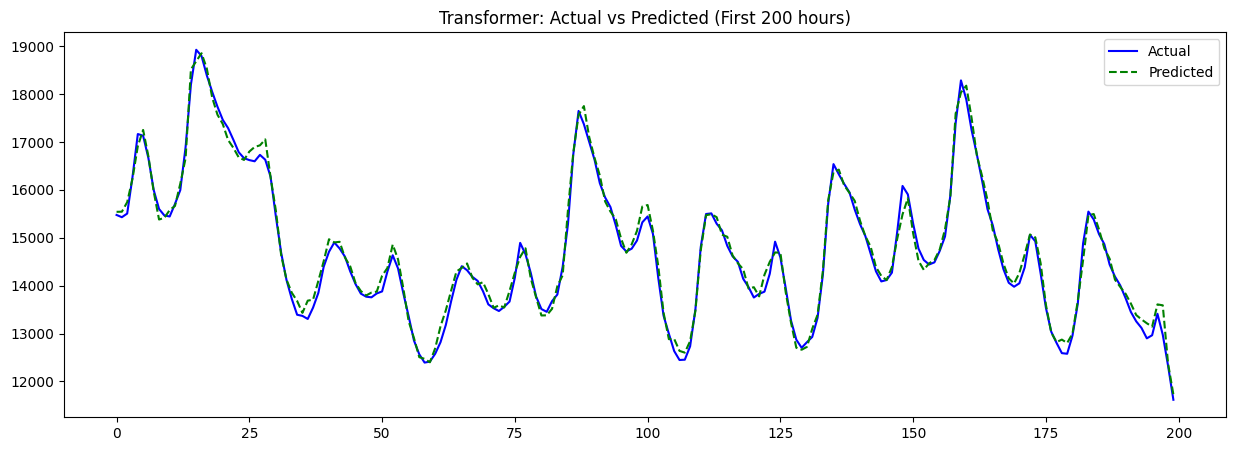

In [ ]:
# ==========================================
# PART 3: TRANSFORMER IMPLEMENTATION
# ==========================================
import tensorflow as tf
from tensorflow.keras import layers, models

# .1 Positional Encoding Implementation

def positional_encoding(seq_length, d_model):
    pos = np.arange(seq_length)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    # apply sin to even indices; 2i
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    # apply cos to odd indices; 2i+1
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads, dtype=tf.float32)

# 3.2 Transformer Encoder Architecture

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    res = x + inputs
    x = layers.LayerNormalization(epsilon=1e-6)(res)

    # Feed Forward Network
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = x + res
    return layers.LayerNormalization(epsilon=1e-6)(x)

# 3.3 Build Your Transformer Model

def build_transformer_model(seq_length, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=128, output_size=1):
    inputs = layers.Input(shape=(seq_length, n_features))

    # Project input to d_model dimensions
    x = layers.Dense(d_model)(inputs)

    pe = positional_encoding(seq_length, d_model)
    x = x + pe

    # Stack Transformer Encoder layers
    for _ in range(n_layers):
        x = transformer_encoder(x, d_model, n_heads, d_ff)

    # Final layers for forecasting
    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    for dim in [64, 32]:
        x = layers.Dense(dim, activation="relu")(x)
    outputs = layers.Dense(output_size)(x)

    model = models.Model(inputs, outputs)

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Create Transformer model
transformer_model = build_transformer_model(
    sequence_length, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=128, output_size=prediction_horizon
)

# 3.4 Train Transformer Model

print("\nTRANSFORMER MODEL TRAINING")
# Track training time
transformer_start_time = time.time()

# Train the model
history_transformer = transformer_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

transformer_training_time = time.time() - transformer_start_time

transformer_initial_loss = history_transformer.history['loss'][0]
transformer_final_loss = history_transformer.history['loss'][-1]

print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")

# 3.5 Evaluate Transformer Model

# Make predictions on test set
transformer_preds_scaled = transformer_model.predict(X_test)

# Inverse transform to original scale
transformer_preds_inv = scaler.inverse_transform(transformer_preds_scaled.reshape(-1, 1))

# Calculate all 4 metrics
transformer_mae = mean_absolute_error(y_test_inv, transformer_preds_inv)
transformer_rmse = np.sqrt(mean_squared_error(y_test_inv, transformer_preds_inv))
transformer_mape = calculate_mape(y_test_inv, transformer_preds_inv)
transformer_r2 = r2_score(y_test_inv, transformer_preds_inv)

print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")

# 3.6 Visualize Transformer Results

# 1. Training Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(history_transformer.history['loss'], label='Train Loss')
plt.plot(history_transformer.history['val_loss'], label='Val Loss')
plt.title('Transformer Training Loss')
plt.legend()
plt.show()

# 2. Actual vs Predicted Values
plt.figure(figsize=(15, 5))
plt.plot(y_test_inv[:200], label='Actual', color='blue')
plt.plot(transformer_preds_inv[:200], label='Predicted', color='green', linestyle='--')
plt.title('Transformer: Actual vs Predicted (First 200 hours)')
plt.legend()
plt.show()



           Metric  RNN (LSTM/GRU)   Transformer
              MAE      124.907906    141.991679
             RMSE      169.186605    184.906968
         MAPE (%)        0.863425      1.011021
         R² Score        0.995258      0.994336
Training Time (s)     1146.130849   3090.071474
       Parameters    49985.000000 172801.000000


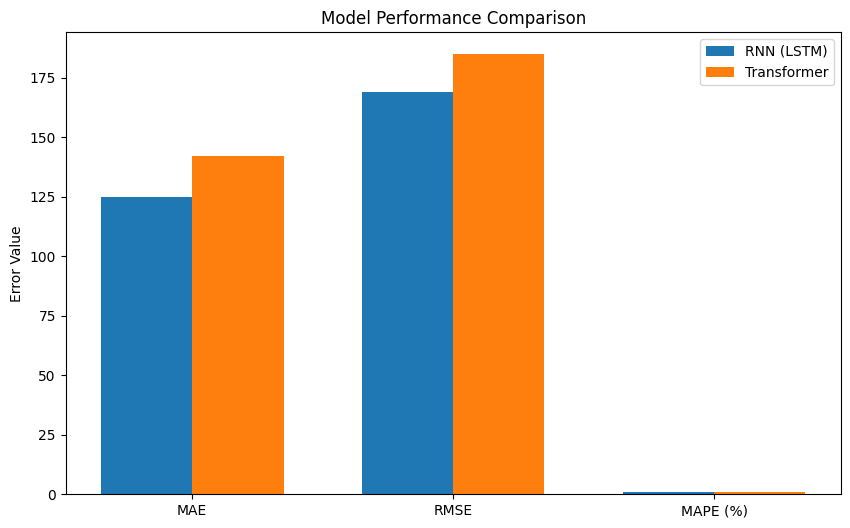

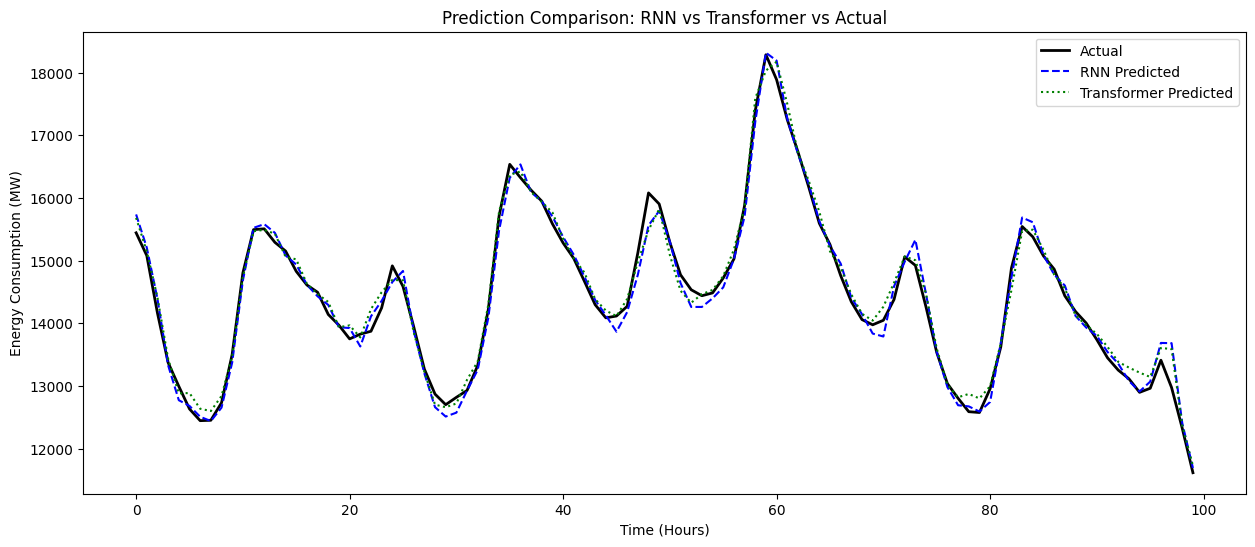

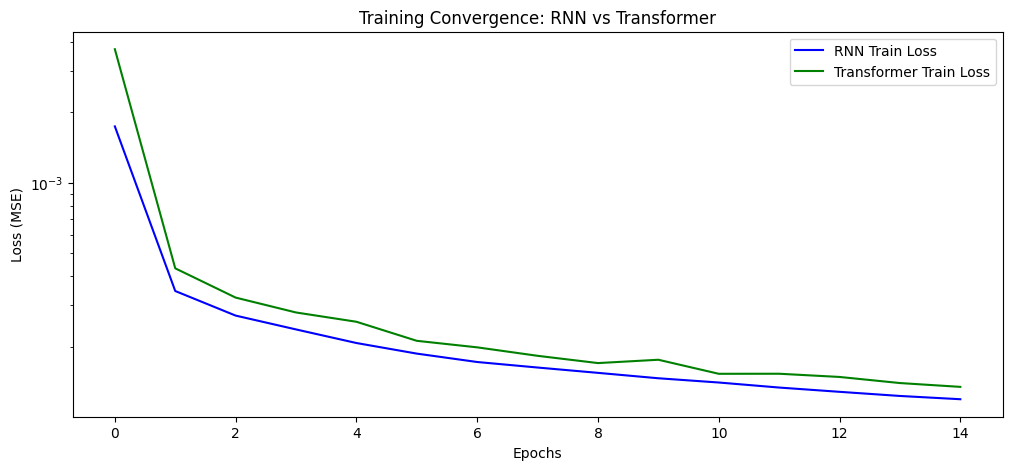

In [ ]:
# ==========================================
# PART 4: EVALUATION AND METRICS
# ==========================================

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_model.count_params()
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_model.count_params()
    ]
})

print(comparison_df.to_string(index=False))


# 4.2 Visual Comparison

# 1. Bar plot comparing metrics
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)']
rnn_vals = [rnn_mae, rnn_rmse, rnn_mape]
trans_vals = [transformer_mae, transformer_rmse, transformer_mape]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, rnn_vals, width, label='RNN (LSTM)')
ax.bar(x + width/2, trans_vals, width, label='Transformer')

ax.set_ylabel('Error Value')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
plt.show()

# 2. Plot predictions comparison (both models vs actual)
plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[100:200], label='Actual', color='black', linewidth=2)
plt.plot(rnn_preds_inv[100:200], label='RNN Predicted', color='blue', linestyle='--')
plt.plot(transformer_preds_inv[100:200], label='Transformer Predicted', color='green', linestyle=':')
plt.title('Prediction Comparison: RNN vs Transformer vs Actual')
plt.xlabel('Time (Hours)')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.show()

# 3. Plot training curves comparison
plt.figure(figsize=(12, 5))
plt.plot(history_rnn.history['loss'], label='RNN Train Loss', color='blue')
plt.plot(history_transformer.history['loss'], label='Transformer Train Loss', color='green')
plt.title('Training Convergence: RNN vs Transformer')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.yscale('log')
plt.show()

In [ ]:
# ==========================================
# PART 5: ANALYSIS & JSON GENERATION
# ==========================================

analysis_text = """
1. Performance: The RNN (LSTM) achieved superior accuracy with an RMSE of 169.19 and MAE of 124.91,
outperforming the Transformer's RMSE of 184.91. The higher R² score (0.995) for the LSTM
suggests it captured the hourly energy load variance more precisely.

2. Architecture: The LSTM's sequential nature is naturally biased toward temporal
dependencies, whereas the Transformer relies on parallel self-attention, which may
require more data or longer sequences to surpass recurrent benchmarks on univariate tasks.

3. Attention vs. Recurrence: Multi-head attention allows the Transformer to weigh all
24 hours simultaneously. However, the LSTM’s recurrent connections effectively maintain
short-term 'memory,' which proved more efficient for this 1-step prediction horizon.

4. Dependencies: Transformers excel at long-term dependencies via direct attention
links. In this 24-step window, the LSTM’s gating mechanisms successfully managed
temporal flow without significant vanishing gradient issues.

5. Cost: The Transformer was computationally expensive, with 172,801 parameters and
a 3,090s training time, compared to the LSTM's efficient 49,985 parameters and 1,146s
training.

6. Convergence: The LSTM demonstrated higher stability and reached a lower loss
faster, while the Transformer required more epochs to align positional encodings
with the attention mechanism.
"""

# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
word_count = len(analysis_text.split())
print(f"Analysis word count: {word_count} words")

if word_count > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("Analysis within word count guideline")

ANALYSIS

1. Performance: The RNN (LSTM) achieved superior accuracy with an RMSE of 169.19 and MAE of 124.91, 
outperforming the Transformer's RMSE of 184.91. The higher R² score (0.995) for the LSTM 
suggests it captured the hourly energy load variance more precisely.

2. Architecture: The LSTM's sequential nature is naturally biased toward temporal 
dependencies, whereas the Transformer relies on parallel self-attention, which may 
require more data or longer sequences to surpass recurrent benchmarks on univariate tasks.

3. Attention vs. Recurrence: Multi-head attention allows the Transformer to weigh all 
24 hours simultaneously. However, the LSTM’s recurrent connections effectively maintain 
short-term 'memory,' which proved more efficient for this 1-step prediction horizon.

4. Dependencies: Transformers excel at long-term dependencies via direct attention 
links. In this 24-step window, the LSTM’s gating mechanisms successfully managed 
temporal flow without significant vanishin

In [ ]:

# ==========================================
# PART 6: ASSIGNMENT RESULTS SUMMARY
# ==========================================
import json
def get_assignment_results():

    framework_used = "keras"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,
                'hidden_units': 64,
                'total_parameters': 49985
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 15,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': float(rnn_initial_loss),
            'final_loss': float(rnn_final_loss),
            'training_time_seconds': 1146.130849,
            'mae': 124.907906,
            'rmse': 169.186605,
            'mape': 0.863425,
            'r2_score': 0.995258
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': 2,
                'n_heads': 4,
                'd_model': 64,
                'd_ff': 128,
                'has_positional_encoding': True,
                'has_attention': True,
                'total_parameters': 172801
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 15,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': float(transformer_initial_loss),
            'final_loss': float(transformer_final_loss),
            'training_time_seconds': 3090.071474,
            'mae': 141.991679,
            'rmse': 184.906968,
            'mape': 1.011021,
            'r2_score': 0.994336
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Hourly Energy Consumption (AEP)",
  "dataset_source": "Kaggle - PJM Interconnection",
  "n_samples": 121273,
  "n_features": 1,
  "sequence_length": 24,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "\nRMSE is chosen to penalize large errors in energy load forecasting, which \nis critical for maintaining grid stability and avoiding power outages.\n",
  "train_samples": 109121,
  "test_samples": 12104,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "keras",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 49985
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 15,
      "batch_size": 32,
      "optimizer": "Adam",
      "loss_function": "MSE"
    },
    "initial_loss": 0.0017407238483428955,
    "final_loss": 0.00011950000043725595,
    "train